In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import umap

from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from imblearn.over_sampling import SMOTE
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
from time import time

seed = 42

## Dataset

In [2]:
df = pd.read_csv("RT_IOT2022", sep=',')
pd.options.display.max_columns = None

display(df)

,Unnamed: 0,id.orig_p,id.resp_p,proto,service,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,Attack_type
0,0,38667,1883,tcp,mqtt,32.011598,9,5,3,3,0.281148,0.156193,0.437341,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,761.985779,2.972918e+07,3.201160e+07,4.001450e+06,1.040307e+07,4438.877106,1.511694e+06,2.026391e+06,506597.757339,680406.147126,761.985779,2.972918e+07,3.201160e+07,2.462431e+06,8.199747e+06,3.373777,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.282415e+06,2.282415e+06,2.282415e+06,2.282415e+06,0.0,2.972918e+07,2.972918e+07,2.972918e+07,2.972918e+07,0.0,64240,26847,502,MQTT_Publish
1,1,51143,1883,tcp,mqtt,31.883584,9,5,3,3,0.282277,0.156821,0.439097,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.0,33.0,108.0,7.714286,11.618477,247.001648,2.985528e+07,3.188358e+07,3.985448e+06,1.046346e+07,4214.048386,1.576436e+06,1.876261e+06,469065.248966,741351.686212,247.001648,2.985528e+07,3.188358e+07,2.452583e+06,8.242459e+06,3.387323,3.0,1.666667,25.333333,10.666667,0.0,0.0,0.0,0.0,0.0,0.0,2.028307e+06,2.028307e+06,2.028307e+06,2.028307e+06,0.0,2.985528e+07,2.985528e+07,2.985528e+07,2.985528e+07,0.0,64240,26847,502,MQTT_Publish
2,2,44761,1883,tcp,mqtt,32.124053,9,5,3,3,0.280164,0.155647,0.435811,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,283.956528,2.984215e+07,3.212405e+07,4.015507e+06,1.044238e+07,2456.903458,1.476049e+06,2.013770e+06,503442.466259,660344.360027,283.956528,2.984215e+07,3.212405e+07,2.471081e+06,8.230593e+06,3.237450,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.281904e+06,2.281904e+06,2.281904e+06,2.281904e+06,0.0,2.984215e+07,2.984215e+07,2.984215e+07,2.984215e+07,0.0,64240,26847,502,MQTT_Publish
3,3,60893,1883,tcp,mqtt,31.961063,9,5,3,3,0.281593,0.156440,0.438033,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,74.0,8.222222,12.852799,0.0,21.0,30.0,6.0,8.689074,0.0,33.0,104.0,7.428571,11.229866,288.963318,2.991377e+07,3.196106e+07,3.995133e+06,1.048253e+07,3933.906555,1.551892e+06,1.883784e+06,470946.013927,724569.317911,288.963318,2.991377e+07,3.196106e+07,2.458543e+06,8.257786e+06,3.253959,3.0,1.666667,24.666667,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,2.047288e+06,2.047288e+06,2.047288e+06,2.047288e+06,0.0,2.991377e+07,2.991377e+07,2.991377e+07,2.991377e+07,0.0,64240,26847,502,MQTT_Publish
4,4,51087,1883,tcp,mqtt,31.902362,9,5,3,3,0.282111,0.156728,0.438839,0.555556,296,32,40,168,32,40,0,2,1,3,3,13,0,0,0,0,0.0,33.0,76.0,8.444444,13.115936,0.0,23.0,32.0,6.4,9.555103,0.

In [3]:
print("Dataset information:")
print(df.info(), "\n")

for col in df.columns:
    print(f"{col}: {df[col].unique()}")

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123117 entries, 0 to 123116
Data columns (total 85 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Unnamed: 0                123117 non-null  int64  
 1   id.orig_p                 123117 non-null  int64  
 2   id.resp_p                 123117 non-null  int64  
 3   proto                     123117 non-null  object 
 4   service                   123117 non-null  object 
 5   flow_duration             123117 non-null  float64
 6   fwd_pkts_tot              123117 non-null  int64  
 7   bwd_pkts_tot              123117 non-null  int64  
 8   fwd_data_pkts_tot         123117 non-null  int64  
 9   bwd_data_pkts_tot         123117 non-null  int64  
 10  fwd_pkts_per_sec          123117 non-null  float64
 11  bwd_pkts_per_sec          123117 non-null  float64
 12  flow_pkts_per_sec         123117 non-null  float64
 13  down_up_ratio          

In [4]:
empty_rows = df[df.isnull().all(axis=1)]
print(empty_rows)

Empty DataFrame
Columns: [Unnamed: 0, id.orig_p, id.resp_p, proto, service, flow_duration, fwd_pkts_tot, bwd_pkts_tot, fwd_data_pkts_tot, bwd_data_pkts_tot, fwd_pkts_per_sec, bwd_pkts_per_sec, flow_pkts_per_sec, down_up_ratio, fwd_header_size_tot, fwd_header_size_min, fwd_header_size_max, bwd_header_size_tot, bwd_header_size_min, bwd_header_size_max, flow_FIN_flag_count, flow_SYN_flag_count, flow_RST_flag_count, fwd_PSH_flag_count, bwd_PSH_flag_count, flow_ACK_flag_count, fwd_URG_flag_count, bwd_URG_flag_count, flow_CWR_flag_count, flow_ECE_flag_count, fwd_pkts_payload.min, fwd_pkts_payload.max, fwd_pkts_payload.tot, fwd_pkts_payload.avg, fwd_pkts_payload.std, bwd_pkts_payload.min, bwd_pkts_payload.max, bwd_pkts_payload.tot, bwd_pkts_payload.avg, bwd_pkts_payload.std, flow_pkts_payload.min, flow_pkts_payload.max, flow_pkts_payload.tot, flow_pkts_payload.avg, flow_pkts_payload.std, fwd_iat.min, fwd_iat.max, fwd_iat.tot, fwd_iat.avg, fwd_iat.std, bwd_iat.min, bwd_iat.max, bwd_iat.tot, bw

Attack_type
DOS_SYN_Hping                 0.768854
Thing_Speak                   0.065856
ARP_poisioning                0.062948
MQTT_Publish                  0.033675
NMAP_UDP_SCAN                 0.021037
NMAP_XMAS_TREE_SCAN           0.016326
NMAP_OS_DETECTION             0.016245
NMAP_TCP_scan                 0.008139
DDOS_Slowloris                0.004337
Wipro_bulb                    0.002055
Metasploit_Brute_Force_SSH    0.000301
NMAP_FIN_SCAN                 0.000227
Name: proportion, dtype: float64

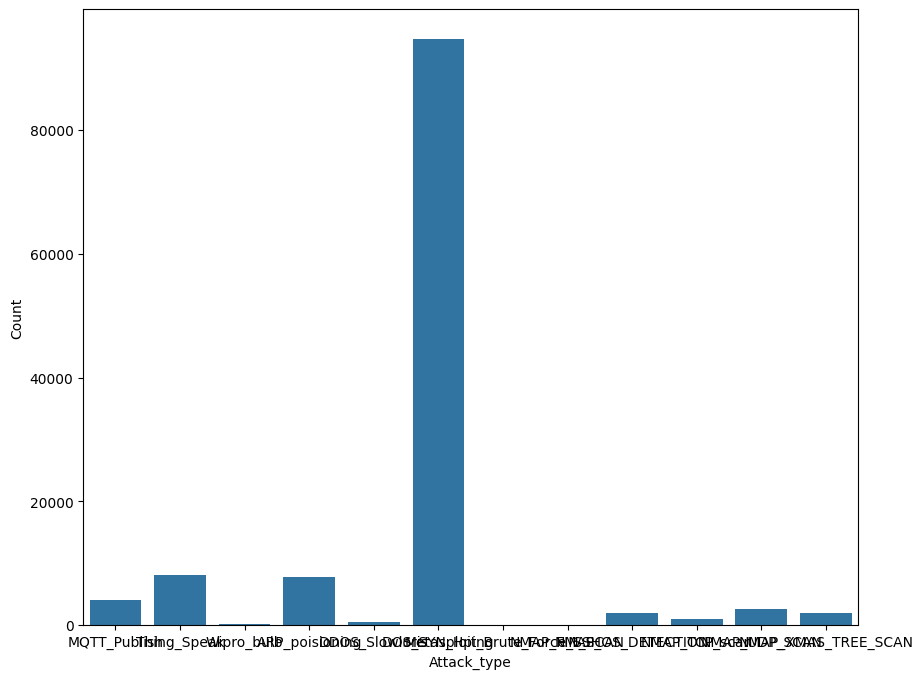

In [5]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Attack_type', data=df)
plt.ylabel('Count')
df['Attack_type'].value_counts(normalize=True)

## Pre-processing

In [14]:
# Split the features and target
X = df.drop(columns=['Attack_type'])
y = df['Attack_type']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=seed, stratify=y)

train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=6, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')